<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Procesos-Estoc-sticos/blob/main/CA__Modificada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria modificada

Consideremos el sistema descrito en la siguiente figura:

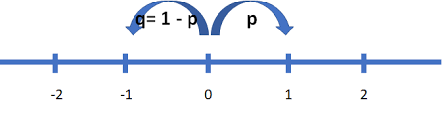

Con probabilidad $p$ de moverse a la derecha y probabilidad $q$ de moverse a la izquierda, tal que $p + q = 1$.

Sea $X_n$ el estado del proceso al tiempo $n$. Está variable cambia de acuerdo a las probabilidades de transición:

$P(X_{n+1}=j|x_n=i)= \left\{\begin{matrix}
p \hspace{0.2cm} si \hspace{0.2cm} j=i+1 \\
q \hspace{0.2cm} si \hspace{0.2cm} j=i-1 \\ 0 \hspace{0.2cm} en \hspace{0.2cm} otro \hspace{0.2cm} caso
\end{matrix}\right.$

Se puede reescribir:

$X_n=x_0+\mu_1+\mu_2+...+\mu_n$, con $x_0=0$

donde $\mu_i$ son variables independientes e identicamente distribuidas, con:

$P(\mu=+1)=p$, $p+q=1$

$P(\mu=-1)=q$

entonces, $\mu$ es una distribución de $Bernoulli(p)$. Por tanto, $X_n$ tiene una distribución $binomial(n,p)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

Modificamos el còdigo de la caminata que ya teníamos, cambiando la posición inicial y agregando dos límites en los cuales si la caminata los toca se detendrá:

In [54]:
def caminata(n_max_steps, p):
  posicion=20 # Se modifica la posición inicial
  camino=[posicion]
  steps_taken = 0
  while posicion != 60 and posicion != 0: # Límites donde la función se detendrá
    a=r.random()
    if a<p:
      posicion=posicion+1
    else:
      posicion=posicion-1
    camino.append(posicion)
    steps_taken += 1
  return camino

Text(0, 0.5, 'Posicion')

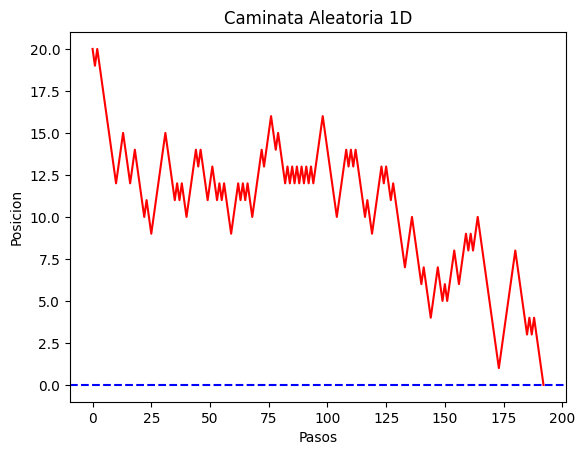

In [93]:
n=1000
p=0.5

cam = caminata(n,p)

plt.title("Caminata Aleatoria 1D")
plt.axhline(0, color='blue', linestyle='--')
plt.plot(cam, color='red')
plt.xlabel("Pasos")
plt.ylabel("Posicion")

¿Cuál es la probabilidad de que la trayectoria llegue a cero?

In [94]:
caminatas_que_tocan_cero=0
m=1000 # Veces que se repite el experimento
for _ in range(m):
  cam = caminata(n, p)
  if 0 in cam:
    caminatas_que_tocan_cero += 1
pd0=caminatas_que_tocan_cero/m

print("De", m,"caminatas, el cero fue tocado en", caminatas_que_tocan_cero, "ocasiones.")
print("La probabilidad de que el cero sea tocado es de", pd0)

De 1000 caminatas, el cero fue tocado en 676 ocasiones.
La probabilidad de que el cero sea tocado es de 0.676


Determinar por simulación la distribución de probabilidad $P(i)=0,1,...,N$

In [95]:
p_final= []
for _ in range(m):
  cam = caminata(n, p)
  p_final.append(cam[-1])

print("Colección final de las posiciones para {} simulaciones.".format(len(p_final)))

Colección final de las posiciones para 1000 simulaciones.


In [96]:
c_0 = p_final.count(0)
c_60 = p_final.count(60)

prob_0 = c_0 / m
prob_60 = c_60 / m

print(f"Probabilidad de terminar en 0: {prob_0:.4f}")
print(f"Probabilidad de terminar 60: {prob_60:.4f}")

Probabilidad de terminar en 0: 0.6810
Probabilidad de terminar 60: 0.3190
